# Lab 7: Batch Gradient Descent, Stochastic Gradient Descent (SGD), and Mini-Batch Gradient Descent using TensorFlow

#### Aim: 
- To implement and compare Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent using TensorFlow, and to analyze their loss convergence behavior.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Problem Statement
- Train a simple neural network to learn the function:
- y = 3x + 2 + noise, using three different gradient descent approaches.

### 1. Dataset Preparation

In [2]:
np.random.seed(42)
X = np.random.rand(1000, 1)
y = 3 * X + 2 + np.random.randn(1000, 1) * 0.1

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### 2. Model Definition

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])

loss_fn = tf.keras.losses.MeanSquaredError()

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Task 1: Batch Gradient Descent
#### Theory:
  - Uses entire dataset to compute gradient
  - Stable but slow for large datasets

In [4]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
loss_history_bgd = []

for epoch in range(50):
    with tf.GradientTape() as tape:
        y_pred = model(X)
        loss = loss_fn(y, y_pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    loss_history_bgd.append(loss.numpy())

### Task 2: Stochastic Gradient Descent (SGD)
- Uses one sample at a time
- Faster updates, noisy convergence

In [6]:
loss_history_sgd = []

for epoch in range(50):
    for i in range(len(X)):
        xi = X[i:i+1]
        yi = y[i:i+1]
        
        with tf.GradientTape() as tape:
            y_pred = model(xi)
            loss = loss_fn(yi, y_pred)
        
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
    
    loss_history_sgd.append(loss.numpy())

### Task 3: Mini-Batch Gradient Descent
#### Theory:
  - Uses small batches of data
  - Balance between speed and stability
  - Most Commonly used in practice

In [5]:
batch_size = 32
loss_history_mbgd = []

for epoch in range(50):
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]
        
        with tf.GradientTape() as tape:
            y_pred = model(xb)
            loss = loss_fn(yb, y_pred)
        
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
    
    loss_history_mbgd.append(loss.numpy())

### Evaluation: Comparative Chart (Loss vs Epoch)

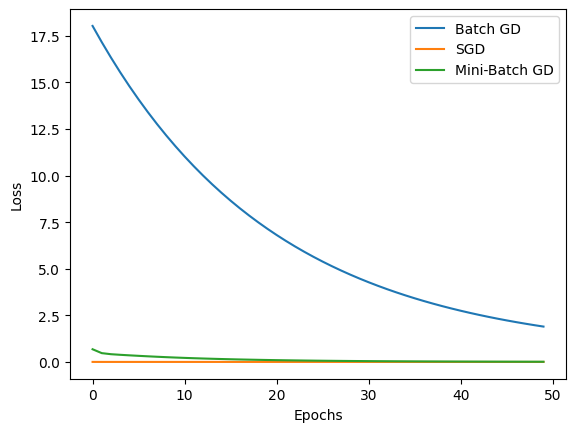

In [7]:
plt.plot(loss_history_bgd, label="Batch GD")
plt.plot(loss_history_sgd, label="SGD")
plt.plot(loss_history_mbgd, label="Mini-Batch GD")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Knowledge Check

1. Why does Batch Gradient Descent have a smooth loss curve but slow convergence?
- Batch Gradient Descent uses the entire dataset to compute gradients, making updates very accurate. This results in a smooth and stable loss curve during training. However, since updates happen only once per epoch, the convergence is slow. It is inefficient for large datasets.
2. What causes fluctuations in the loss function when using SGD?
- SGD updates weights using one sample at a time, so gradients vary frequently. This causes a noisy or fluctuating loss curve.
3. Why is Mini-Batch Gradient Descent preferred for training deep neural networks?
- Mini-Batch GD uses small batches, giving faster updates than Batch GD and less noise than SGD. It provides the best balance between speed and stability.
4. What happens if the batch size is increased to the full dataset?
- The method becomes Batch Gradient Descent.This results in smooth but slower training.
5. How does shuffling the dataset affect SGD and Mini-Batch GD?
- Shuffling randomizes data order and prevents learning biased patterns. It improves convergence and training stability.

### Exercise 1: Effect of Learning Rate
- Objective: To study the effect of learning rate on convergence behavior.
- Task: - Train the same model using Mini-Batch Gradient Descent - Use learning rates: 0.001, 0.01, and 0.1 - Plot loss vs epochs for each case
- Questions: 1. Which learning rate converges fastest? 2. Which learning rate causes instability? 3. What happens if the learning rate is too small?